In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)


!pip install matplotlib

In [2]:
file_path = "LD2011_2014.txt"

data = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    index_col=0
)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (140256, 370)


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
data.index = pd.to_datetime(data.index)
data.index[:5]


DatetimeIndex(['2011-01-01 00:15:00', '2011-01-01 00:30:00',
               '2011-01-01 00:45:00', '2011-01-01 01:00:00',
               '2011-01-01 01:15:00'],
              dtype='datetime64[us]', freq=None)

In [4]:
data.index.to_series().diff().value_counts().head()


0 days 00:15:00    140255
Name: count, dtype: int64

In [5]:
print("Number of consumers:", data.shape[1])


Number of consumers: 370


In [6]:
data.describe().iloc[:, :5]


,MT_001,MT_002,MT_003,MT_004,MT_005
count,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,3.970785,20.768480,2.918308,82.184490,37.240309
std,5.983965,13.272415,11.014456,58.248392,26.461327
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.844950,0.000000,36.585366,15.853659
50%,1.269036,24.893314,1.737619,87.398374,39.024390
75%,2.538071,29.871977,1.737619,115.853659,54.878049
max,48.223350,115.220484,151.172893,321.138211,150.000000


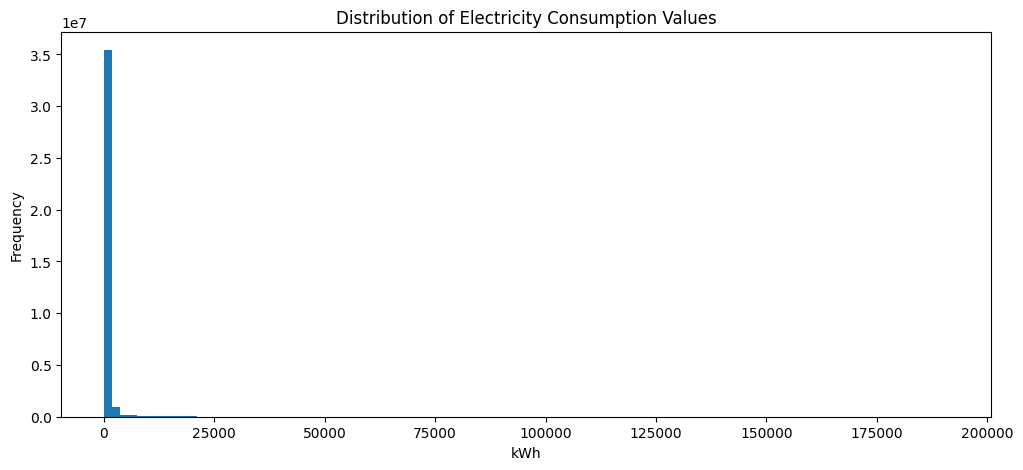

In [7]:
sample_values = data.sample(100000).values.flatten()

plt.hist(sample_values, bins=100)
plt.title("Distribution of Electricity Consumption Values")
plt.xlabel("kWh")
plt.ylabel("Frequency")
plt.show()


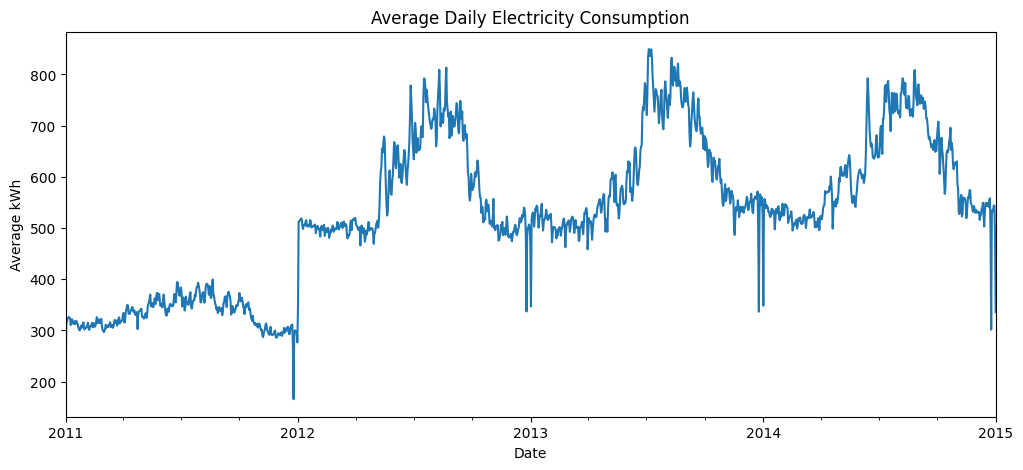

In [8]:
daily_avg = data.resample("D").mean().mean(axis=1)

daily_avg.plot()
plt.title("Average Daily Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Average kWh")
plt.show()


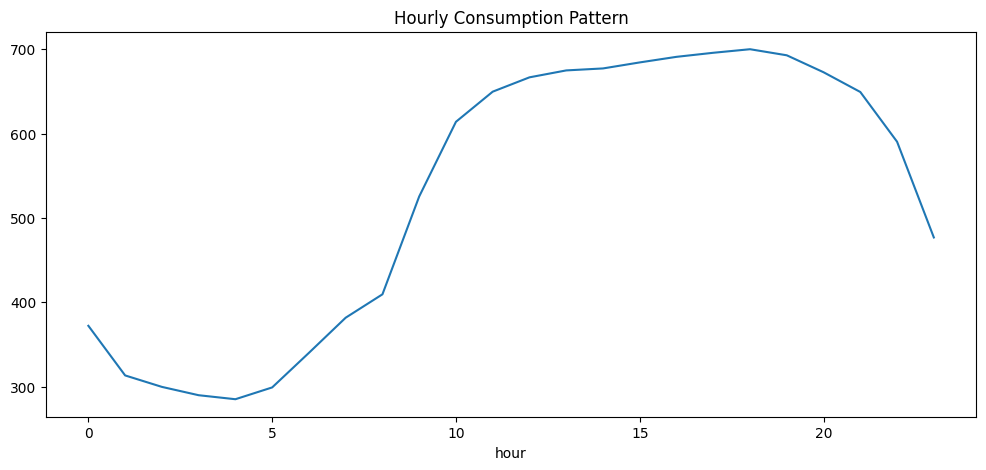

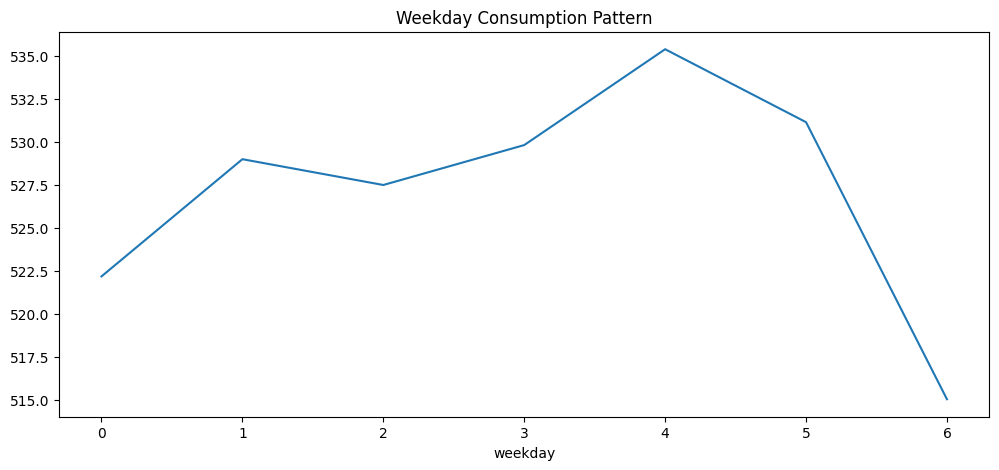

In [9]:
analysis_data = data.copy()

analysis_data["hour"] = analysis_data.index.hour
analysis_data["weekday"] = analysis_data.index.weekday

hourly_pattern = analysis_data.groupby("hour").mean().mean(axis=1)
weekday_pattern = analysis_data.groupby("weekday").mean().mean(axis=1)

hourly_pattern.plot(title="Hourly Consumption Pattern")
plt.show()

weekday_pattern.plot(title="Weekday Consumption Pattern")
plt.show()


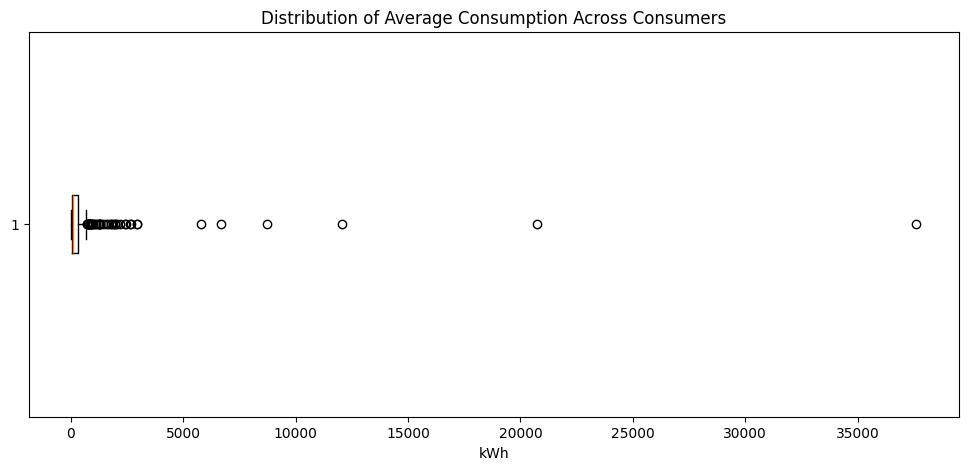

In [10]:
consumer_means = data.mean()

plt.boxplot(consumer_means, vert=False)
plt.title("Distribution of Average Consumption Across Consumers")
plt.xlabel("kWh")
plt.show()


In [11]:
data.isnull().sum().sum()


np.int64(0)

In [12]:
data_filled = data.ffill().bfill()


In [13]:
output_path = "cleaned_consumption.csv"
data_filled.to_csv(output_path)

print("Cleaned data saved successfully")


Cleaned data saved successfully


In [14]:
data = pd.read_csv(
    "cleaned_consumption.csv",
    index_col=0,
    parse_dates=True
)


In [15]:
import pandas as pd
import numpy as np

features = []

for meter in data.columns:

    meter_data = data[meter]

    avg_consumption = meter_data.mean()
    max_consumption = meter_data.max()
    std_dev = meter_data.std()

    load_factor = avg_consumption / max_consumption if max_consumption != 0 else 0

    features.append({
        "consumer_id": meter,
        "avg_consumption": avg_consumption,
        "max_consumption": max_consumption,
        "variability": std_dev,
        "load_factor": load_factor
    })

features_df = pd.DataFrame(features)

features_df.head()

,consumer_id,avg_consumption,max_consumption,variability,load_factor
0,MT_001,3.970785,48.223350,5.983965,0.082342
1,MT_002,20.768480,115.220484,13.272415,0.180250
2,MT_003,2.918308,151.172893,11.014456,0.019304
3,MT_004,82.184490,321.138211,58.248392,0.255916
4,MT_005,37.240309,150.000000,26.461327,0.248269


In [16]:
X = features_df[['avg_consumption','max_consumption','variability','load_factor']]

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
from sklearn.ensemble import IsolationForest


iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [21]:
features_df["anomaly_score"] = iso_forest.decision_function(X_scaled)
features_df["anomaly_label"] = iso_forest.predict(X_scaled)

features_df.head()

,consumer_id,avg_consumption,max_consumption,variability,load_factor,anomaly_score,anomaly_label
0,MT_001,3.970785,48.223350,5.983965,0.082342,0.123481,1
1,MT_002,20.768480,115.220484,13.272415,0.180250,0.170299,1
2,MT_003,2.918308,151.172893,11.014456,0.019304,0.084727,1
3,MT_004,82.184490,321.138211,58.248392,0.255916,0.187038,1
4,MT_005,37.240309,150.000000,26.461327,0.248269,0.187957,1


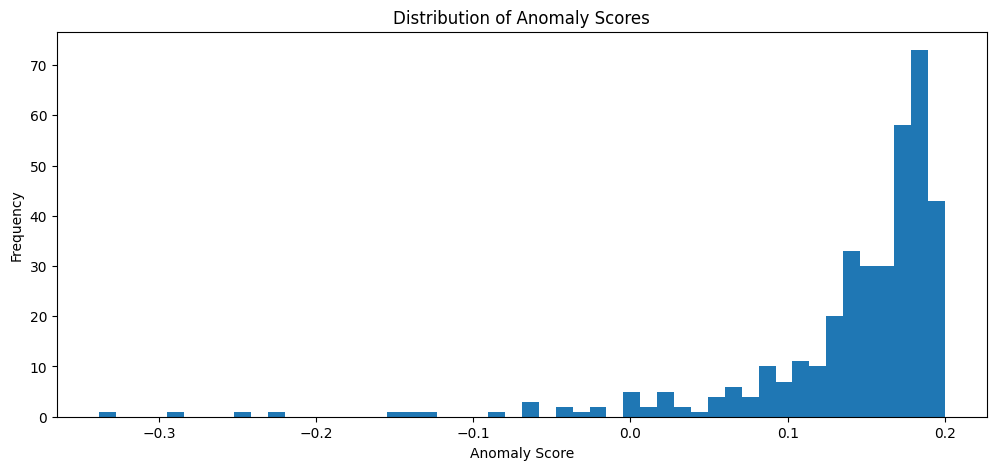

In [22]:
plt.hist(features_df["anomaly_score"], bins=50)
plt.title("Distribution of Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

In [23]:
def risk(row):

    if row["anomaly_label"] == -1:
        return "High"

    elif row["anomaly_score"] < 0:
        return "Medium"

    else:
        return "Low"

features_df["risk_level"] = features_df.apply(risk, axis=1)

In [24]:
def generate_explanation(row):
    if row["anomaly_label"] == -1:
        return "Unusual consumption detected"
    else:
        return "Normal consumption pattern"

features_df["explanation"] = features_df.apply(generate_explanation, axis=1)

In [25]:
features_df.to_csv(
    "data/processed/explainable_anomalies.csv",
    index=False
)

print("Consumer anomaly dataset saved")

Consumer anomaly dataset saved


In [26]:
features_df.sort_values("anomaly_score").head(10)

,consumer_id,avg_consumption,max_consumption,variability,load_factor,anomaly_score,anomaly_label,risk_level,explanation
361,MT_362,37607.987537,192800.000000,38691.954832,0.195062,-0.338068,-1,High,Unusual consumption detected
195,MT_196,20744.150874,78541.666667,7339.107947,0.264117,-0.290239,-1,High,Unusual consumption detected
369,MT_370,8722.355145,30918.918919,9195.155777,0.282104,-0.244186,-1,High,Unusual consumption detected
278,MT_279,12038.971232,21414.166667,3130.464062,0.562197,-0.225073,-1,High,Unusual consumption detected
207,MT_208,6662.030067,14218.487395,2081.556920,0.468547,-0.152415,-1,High,Unusual consumption detected
227,MT_228,5782.656826,10473.684211,1967.855665,0.552113,-0.136978,-1,High,Unusual consumption detected
363,MT_364,2940.031734,12386.363636,2732.251967,0.237360,-0.130284,-1,High,Unusual consumption detected
338,MT_339,2442.715562,9930.081301,2128.834941,0.245991,-0.090499,-1,High,Unusual consumption detected
219,MT_220,2951.449898,7075.949367,1229.487553,0.417110,-0.065286,-1,High,Unusual consumption detected
223,MT_224,1287.956127,6770.579710,1767.135329,0.190228,-0.060657,-1,High,Unusual consumption detected


In [27]:
features_df["anomaly_label"].value_counts()

anomaly_label
 1    351
-1     19
Name: count, dtype: int64

In [28]:
features_df["risk_level"].value_counts()

risk_level
Low     351
High     19
Name: count, dtype: int64

In [29]:
features_df["anomaly_score"].describe()

count    370.000000
mean       0.139968
std        0.073243
min       -0.338068
25%        0.129466
50%        0.162467
75%        0.182127
max        0.199890
Name: anomaly_score, dtype: float64

In [32]:
import os
import joblib
os.makedirs("../backend/model", exist_ok=True)

joblib.dump(iso_forest, "../backend/model/trained_model.pkl")
joblib.dump(scaler, "../backend/model/scaler.pkl")

print("Everything saved successfully")

Everything saved successfully
